In [1]:
# Load environment variables and set up auto-reload
from dotenv import load_dotenv
load_dotenv()

%load_ext autoreload
%autoreload 2

# RAG-Based Documentation Assistant

*Build a documentation assistant that uses Retrieval-Augmented Generation (RAG) to answer questions about your docs.*

This notebook demonstrates how to build a production-ready docs assistant using:
- **Qdrant Cloud** as the vector database for semantic search
- **OpenAI Embeddings** for document vectorization
- **LangGraph** for the agent workflow

![RAG Architecture](https://miro.medium.com/v2/resize:fit:1400/format:webp/1*N7xCa9NxfP25o3cPd3zVMQ.png)

## Prerequisites

Before running this notebook, you need:

1. **Qdrant Cloud Account**: Sign up at [cloud.qdrant.io](https://cloud.qdrant.io)
2. **Environment Variables**: Add to your `.env` file:
   ```
   QDRANT_URL=https://your-cluster-id.qdrant.tech
   QDRANT_API_KEY=your_api_key_here
   OPENAI_API_KEY=your_openai_key_here
   ```

3. **Ingest Documents**: Run the ingestion script first:
   ```bash
   python scripts/ingest_docs.py --docs-dir ./docs --collection docs_assistant
   ```

## State Definitions

First, we define the state objects for our docs assistant. Following the pattern from the research agent, we use `TypedDict` with `Annotated` types for message accumulation.

In [2]:
%%writefile ../src/deep_research_from_scratch/state_docs.py

"""State Definitions for Docs Assistant.

This module defines the state objects for the RAG-based documentation
assistant workflow, including message history and retrieval metadata.
"""

import operator
from typing_extensions import Annotated, List, Sequence, TypedDict

from langchain_core.messages import BaseMessage
from langgraph.graph.message import add_messages


class DocsAssistantState(TypedDict):
    """State for the docs assistant containing message history and retrieval metadata."""

    messages: Annotated[Sequence[BaseMessage], add_messages]
    retrieved_docs: str  # Compressed retrieved context
    raw_notes: Annotated[List[str], operator.add]


class DocsAssistantOutputState(TypedDict):
    """Output state for the docs assistant."""

    answer: str
    retrieved_docs: str
    raw_notes: Annotated[List[str], operator.add]
    messages: Annotated[Sequence[BaseMessage], add_messages]

Overwriting ../src/deep_research_from_scratch/state_docs.py


## RAG Tools

Now we create the Qdrant search tool. This tool:
1. Embeds the query using OpenAI's `text-embedding-3-small` model
2. Searches the Qdrant collection for similar documents
3. Returns formatted results with source information

We use lazy initialization for the Qdrant client to ensure compatibility with LangGraph Platform deployment.

In [3]:
%%writefile ../src/deep_research_from_scratch/rag_tools.py

"""RAG Tools for Docs Assistant.

This module provides Qdrant-based retrieval tools for the docs assistant,
including vector search and document retrieval functionality.
"""

import os
from typing_extensions import Annotated

from langchain_core.tools import InjectedToolArg, tool
from langchain_openai import OpenAIEmbeddings
from qdrant_client import QdrantClient

# ===== CONFIGURATION =====

# Lazy initialization for LangGraph Platform compatibility
_qdrant_client = None
_embeddings = None

# Default collection name
DEFAULT_COLLECTION = "docs_assistant"


def get_qdrant_client() -> QdrantClient:
    """Get or initialize Qdrant client lazily."""
    global _qdrant_client
    if _qdrant_client is None:
        url = os.environ.get("QDRANT_URL")
        api_key = os.environ.get("QDRANT_API_KEY")
        if not url or not api_key:
            raise ValueError(
                "QDRANT_URL and QDRANT_API_KEY environment variables must be set"
            )
        _qdrant_client = QdrantClient(url=url, api_key=api_key)
    return _qdrant_client


def get_embeddings() -> OpenAIEmbeddings:
    """Get or initialize embeddings model lazily."""
    global _embeddings
    if _embeddings is None:
        _embeddings = OpenAIEmbeddings(model="text-embedding-3-small")
    return _embeddings


# ===== RAG TOOL =====


@tool(parse_docstring=True)
def qdrant_search(
    query: str,
    top_k: Annotated[int, InjectedToolArg] = 5,
    collection_name: Annotated[str, InjectedToolArg] = DEFAULT_COLLECTION,
) -> str:
    """Search documentation using semantic similarity.

    Retrieves relevant document chunks from the vector database based on
    the query. Use this to find information in the indexed documentation.

    Args:
        query: The search query to find relevant documentation
        top_k: Number of results to return
        collection_name: Name of the Qdrant collection to search

    Returns:
        Formatted string of retrieved document chunks with sources
    """
    client = get_qdrant_client()
    embeddings = get_embeddings()

    # Generate query embedding
    query_vector = embeddings.embed_query(query)

    # Search Qdrant using query_points (new API)
    results = client.query_points(
        collection_name=collection_name,
        query=query_vector,
        limit=top_k,
    )

    if not results.points:
        return "No relevant documents found for the query."

    # Format results
    formatted_output = "Retrieved Documentation:\n\n"
    for i, point in enumerate(results.points, 1):
        payload = point.payload
        formatted_output += f"--- DOCUMENT {i} (Score: {point.score:.3f}) ---\n"
        formatted_output += f"Source: {payload.get('source', 'Unknown')}\n"
        formatted_output += f"Content:\n{payload.get('content', '')}\n\n"
        formatted_output += "-" * 60 + "\n"

    return formatted_output

Overwriting ../src/deep_research_from_scratch/rag_tools.py


## Docs Assistant Agent

Now we build the main agent following the same pattern as the research agent:

1. **llm_call** - Invokes the model with tools to decide next action
2. **tool_node** - Executes tool calls (qdrant_search, think_tool)
3. **compress_research** - Formats the final answer

The agent uses conditional routing: if the LLM makes tool calls, continue the loop; otherwise, compress and output.

In [4]:
%%writefile ../src/deep_research_from_scratch/docs_assistant.py

"""Docs Assistant Implementation.

This module implements a RAG-based documentation assistant that can
search indexed documentation and answer questions using retrieved context.
"""

from typing_extensions import Literal

from langchain.chat_models import init_chat_model
from langchain_core.messages import (
    HumanMessage,
    SystemMessage,
    ToolMessage,
    filter_messages,
)
from langgraph.graph import END, START, StateGraph

from deep_research_from_scratch.rag_tools import qdrant_search
from deep_research_from_scratch.state_docs import (
    DocsAssistantOutputState,
    DocsAssistantState,
)
from deep_research_from_scratch.utils import get_today_str, think_tool

# ===== CONFIGURATION =====

tools = [qdrant_search, think_tool]
tools_by_name = {tool.name: tool for tool in tools}

model = init_chat_model(model="anthropic:claude-sonnet-4-6")
model_with_tools = model.bind_tools(tools)

# ===== PROMPTS =====

docs_assistant_prompt = """You are a documentation assistant. Your job is to answer questions about the indexed documentation using the qdrant_search tool.

Today's date is {date}.

<Task>
Use the qdrant_search tool to find relevant documentation and answer the user's question accurately.
After each search, use think_tool to assess whether you have enough information to provide a complete answer.
</Task>

<Instructions>
1. Read the user's question carefully to understand what they're asking
2. Search for relevant documentation using qdrant_search with appropriate queries
3. Use think_tool to reflect on the findings and assess if you have sufficient information
4. If needed, search with different or more specific queries to fill gaps
5. Provide a comprehensive, accurate answer based on the retrieved documentation
6. Always cite your sources by mentioning which documents the information came from
</Instructions>

<Hard Limits>
- Use 1-3 search queries maximum per question
- Stop searching when you have sufficient documentation to answer
- If the documentation doesn't contain the answer, say so clearly
- Always cite sources in your final response
</Hard Limits>
"""

# ===== AGENT NODES =====


def llm_call(state: DocsAssistantState):
    """Analyze current state and decide on next actions."""
    return {
        "messages": [
            model_with_tools.invoke(
                [SystemMessage(content=docs_assistant_prompt.format(date=get_today_str()))]
                + list(state["messages"])
            )
        ]
    }


def tool_node(state: DocsAssistantState):
    """Execute all tool calls from the previous LLM response."""
    tool_calls = state["messages"][-1].tool_calls

    observations = []
    for tool_call in tool_calls:
        tool = tools_by_name[tool_call["name"]]
        observations.append(tool.invoke(tool_call["args"]))

    tool_outputs = [
        ToolMessage(
            content=observation, name=tool_call["name"], tool_call_id=tool_call["id"]
        )
        for observation, tool_call in zip(observations, tool_calls)
    ]

    return {"messages": tool_outputs}


def compress_research(state: DocsAssistantState) -> dict:
    """Compress retrieved documentation into final answer."""
    # Extract raw notes from retrieval
    raw_notes = [
        str(m.content)
        for m in filter_messages(state["messages"], include_types=["tool", "ai"])
    ]

    # Get the final AI response as the answer
    final_message = state["messages"][-1]
    answer = str(final_message.content) if hasattr(final_message, "content") else ""

    return {
        "answer": answer,
        "retrieved_docs": "\n".join(raw_notes),
        "raw_notes": ["\n".join(raw_notes)],
    }


# ===== ROUTING LOGIC =====


def should_continue(state: DocsAssistantState) -> Literal["tool_node", "compress_research"]:
    """Determine whether to continue or provide final answer."""
    messages = state["messages"]
    last_message = messages[-1]

    if last_message.tool_calls:
        return "tool_node"
    return "compress_research"


# ===== GRAPH CONSTRUCTION =====

agent_builder = StateGraph(DocsAssistantState, output_schema=DocsAssistantOutputState)

agent_builder.add_node("llm_call", llm_call)
agent_builder.add_node("tool_node", tool_node)
agent_builder.add_node("compress_research", compress_research)

agent_builder.add_edge(START, "llm_call")
agent_builder.add_conditional_edges(
    "llm_call",
    should_continue,
    {
        "tool_node": "tool_node",
        "compress_research": "compress_research",
    },
)
agent_builder.add_edge("tool_node", "llm_call")
agent_builder.add_edge("compress_research", END)

docs_assistant = agent_builder.compile()

Overwriting ../src/deep_research_from_scratch/docs_assistant.py


## Visualize the Agent Graph

Let's visualize the agent workflow to understand the control flow.

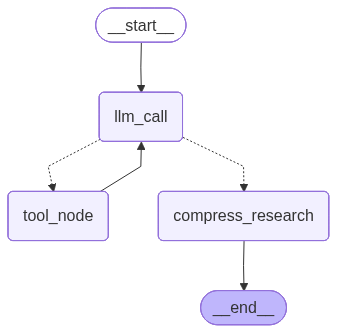

In [5]:
from IPython.display import Image, display
from deep_research_from_scratch.docs_assistant import docs_assistant

display(Image(docs_assistant.get_graph(xray=True).draw_mermaid_png()))

## Test the Agent

Now let's test the docs assistant with a sample query. Make sure you've ingested documents first!

```bash
# Create a docs folder with some markdown files first
mkdir -p docs
echo "# Getting Started\n\nThis is a sample document." > docs/getting_started.md

# Ingest the documents
python scripts/ingest_docs.py --docs-dir ./docs --collection docs_assistant
```

In [6]:
# # Create a docs folder with some markdown files first
# mkdir -p docs
# echo "# Getting Started\n\nThis is a sample document." > docs/getting_started.md

# # Ingest the documents
# python scripts/ingest_docs.py --docs-dir ./docs --collection docs_assistant

In [7]:
from langchain_core.messages import HumanMessage
from deep_research_from_scratch.docs_assistant import docs_assistant

# Test query
result = docs_assistant.invoke({
    "messages": [HumanMessage(content="How do I get started?")]
})

print("Answer:")
print(result["answer"])

Answer:
Based on my search of the available documentation, I found very limited information about getting started. The documentation appears to contain only minimal or placeholder content:

- **getting_started.md**: Contains only a header "Getting Started" followed by "This is a sample document"
- **trial.txt**: Contains only "ABC"

Unfortunately, the indexed documentation doesn't contain comprehensive getting started instructions, setup guides, or detailed steps to help you begin. The available content appears to be sample or placeholder material rather than complete documentation.

To get started, you would likely need to:
1. Look for additional documentation sources not currently indexed
2. Check the project's official website or repository
3. Consult with the project maintainers or community for proper getting started guides

I apologize that I cannot provide more specific guidance based on the current documentation available to me.


In [8]:
# View the full conversation
from utils import format_messages
format_messages(result['messages'])

╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ How do I get started?                                                                                           │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ I'll search the documentation to find information about getting started.                                        │
│                                                                                                                 │
│ 🔧 Tool Call: qdrant_search                                                                                     │
│    Args: {                                                                                                      │
│   "query": "getting started how to start begin setup installation"                                              │
│ }                                                                                                               │
│    ID: toolu_01CbfWL7coeNkRbzx8N7QitZ                                                                           │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Retrieved Documentation:                                                                                        │
│                                                                                                                 │
│ --- DOCUMENT 1 (Score: 0.377) ---                                                                               │
│ Source: getting_started.md                                                                                      │
│ Content:                                                                                                        │
│ "# Getting Started\n\nThis is a sample document.                                                                │
│                                                                                                                 │
│ ------------------------------------------------------------                                                    │
│ --- DOCUMENT 2 (Score: 0.154) ---                                                                               │
│ Source: trial.txt                                                                                               │
│ Content:                                                                                                        │
│ ABC                                                                                                             │
│                                                                                                                 │
│ ------------------------------------------------------------                                                    │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│ 🔧 Tool Call: think_tool                                                                                        │
│    Args: {                                                                                                      │
│   "reflection": "I searched for getting started information but the results are quite limited. The main         │
│ relevant document is \"getting_started.md\" which appears to be just a header \"# Getting Started\" followed by │
│ \"This is a sample document.\" The second result from \"trial.txt\" just contains \"ABC\" which isn't           │
│ helpful.\n\nThe documentation appears to be very minimal or incomplete. I don't have sufficient information to  │
│ provide a comprehensive answer about how to get started. Let me try a more specific search to see if there are  │
│ any setup or installation instructions elsewhere in the documentation."                                         │
│ }                                                                                                               │
│    ID: toolu_01JKyPYQfD1AoVJjhYyktcGp                                                                           │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Reflection recorded: I searched for getting started information but the results are quite limited. The main     │
│ relevant document is "getting_started.md" which appears to be just a header "# Getting Started" followed by     │
│ "This is a sample document." The second result from "trial.txt" just contains "ABC" which isn't helpful.        │
│                                                                                                                 │
│ The documentation appears to be very minimal or incomplete. I don't have sufficient information to provide a    │
│ comprehensive answer about how to get started. Let me try a more specific search to see if there are any setup  │
│ or installation instructions elsewhere in the documentation.                                                    │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│ 🔧 Tool Call: qdrant_search                                                                                     │
│    Args: {                                                                                                      │
│   "query": "setup installation configuration quickstart tutorial first steps"                                   │
│ }                                                                                                               │
│    ID: toolu_013wpH4ZDrDxwMrE4j5zNiMM                                                                           │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Retrieved Documentation:                                                                                        │
│                                                                                                                 │
│ --- DOCUMENT 1 (Score: 0.334) ---                                                                               │
│ Source: getting_started.md                                                                                      │
│ Content:                                                                                                        │
│ "# Getting Started\n\nThis is a sample document.                                                                │
│                                                                                                                 │
│ ------------------------------------------------------------                                                    │
│ --- DOCUMENT 2 (Score: 0.099) ---                                                                               │
│ Source: trial.txt                                                                                               │
│ Content:                                                                                                        │
│ ABC                                                                                                             │
│                                                                                                                 │
│ ------------------------------------------------------------                                                    │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│ 🔧 Tool Call: think_tool                                                                                        │
│    Args: {                                                                                                      │
│   "reflection": "I've now searched twice with different queries related to getting started, setup, and          │
│ installation, but I'm consistently getting the same limited results:\n\n1. A \"getting_started.md\" file that   │
│ only contains a header and \"This is a sample document\"\n2. A \"trial.txt\" file with just \"ABC\"\n\nThis     │
│ suggests that the indexed documentation is either very minimal, incomplete, or possibly just contains           │
│ sample/placeholder content. I don't have sufficient information to provide meaningful guidance on how to get    │
│ started, as the documentation doesn't contain actual instructions, setup steps, or detailed information.\n\nI   │
│ should inform the user about this limitation and suggest they might need to look elsewhere for getting started  │
│ information."                                                                                                   │
│ }                                                                                                               │
│    ID: toolu_01UJKGE5WFqNnMyZH4Gvy1Zh                                                                           │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Reflection recorded: I've now searched twice with different queries related to getting started, setup, and      │
│ installation, but I'm consistently getting the same limited results:                                            │
│                                                                                                                 │
│ 1. A "getting_started.md" file that only contains a header and "This is a sample document"                      │
│ 2. A "trial.txt" file with just "ABC"                                                                           │
│                                                                                                                 │
│ This suggests that the indexed documentation is either very minimal, incomplete, or possibly just contains      │
│ sample/placeholder content. I don't have sufficient information to provide meaningful guidance on how to get    │
│ started, as the documentation doesn't contain actual instructions, setup steps, or detailed information.        │
│                                                                                                                 │
│ I should inform the user about this limitation and suggest they might need to look elsewhere for getting        │
│ started information.                                                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ Based on my search of the available documentation, I found very limited information about getting started. The  │
│ documentation appears to contain only minimal or placeholder content:                                           │
│                                                                                                                 │
│ - **getting_started.md**: Contains only a header "Getting Started" followed by "This is a sample document"      │
│ - **trial.txt**: Contains only "ABC"                                                                            │
│                                                                                                                 │
│ Unfortunately, the indexed documentation doesn't contain comprehensive getting started instructions, setup      │
│ guides, or detailed steps to help you begin. The available content appears to be sample or placeholder material │
│ rather than complete documentation.                                                                             │
│                                                                                                                 │
│ To get started, you would likely need to:                                                                       │
│ 1. Look for additional documentation sources not currently indexed                                              │
│ 2. Check the project's official website or repository                                                           │
│ 3. Consult with the project maintainers or community for proper getting started guides                          │
│                                                                                                                 │
│ I apologize that I cannot provide more specific guidance based on the current documentation available to me.    │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

## Deployment

The docs assistant is now registered in `langgraph.json` and can be deployed.

### Local Development with LangGraph Studio

Run locally with LangGraph Studio:

```bash
uvx --refresh --from "langgraph-cli[inmem]" --with-editable . --python 3.11 langgraph dev
```

This will open LangGraph Studio in your browser where you can:
- Test the `docs_assistant` graph interactively
- View execution traces
- Debug tool calls and responses

### Production Deployment

For production deployment to LangGraph Cloud:

```bash
langgraph deploy
```

Make sure your environment variables are configured in the deployment environment:
- `QDRANT_URL`
- `QDRANT_API_KEY`
- `OPENAI_API_KEY`
- `ANTHROPIC_API_KEY`

## Document Ingestion

The `scripts/ingest_docs.py` script handles document ingestion into Qdrant.

### Usage

```bash
# Basic usage - ingest docs from a directory
python scripts/ingest_docs.py --docs-dir ./docs

# Custom collection name
python scripts/ingest_docs.py --docs-dir ./docs --collection my_project_docs

# Recreate collection (delete existing and start fresh)
python scripts/ingest_docs.py --docs-dir ./docs --recreate

# Custom chunking settings
python scripts/ingest_docs.py --docs-dir ./docs --chunk-size 500 --chunk-overlap 100
```

### Supported File Types
- `.md` - Markdown files
- `.txt` - Plain text files
- `.markdown` - Markdown files (alternate extension)
- `.rst` - reStructuredText files

## Summary

In this notebook, we built a RAG-based documentation assistant with:

1. **Qdrant Cloud** for scalable vector search
2. **OpenAI Embeddings** for semantic document understanding
3. **LangGraph Agent** for intelligent query routing and tool usage

The agent follows the same patterns as the research agent:
- `llm_call` -> `tool_node` -> `llm_call` loop for iterative retrieval
- `compress_research` for final answer generation
- Conditional routing based on tool calls

### Next Steps

1. **Add more tools**: Integrate with the existing research tools (Tavily search) for hybrid retrieval
2. **Improve chunking**: Experiment with different chunk sizes and overlap
3. **Add metadata filtering**: Filter by document type, date, or custom metadata
4. **Implement evaluation**: Add LangSmith evals similar to notebook 1